# Product Experimentation with Synthetic Control: Causal Inference for Global LLM Rollouts in Python

**Keywords:** product experimentation, causal inference, synthetic control, LLM applications, generative AI, global rollout, counterfactual construction

## What this notebook does

Measures the causal effect of a global LLM model upgrade using synthetic control. The scenario: every wave-1 workspace received a new model at week 20 simultaneously. There is no randomized holdout. Synthetic control builds a counterfactual by finding a weighted combination of untreated wave-2 workspaces whose pre-period task completion trajectory matches wave 1. The post-period gap between wave 1 and its synthetic twin is the estimated causal effect, conditional on three identification assumptions: pre-period fit (convex-hull condition), no interference from the treatment to donors (SUTVA for donors), and stable donor composition (no structural breaks in the post-period). Covers SLSQP weight optimization, pre/post trajectory visualization, in-space placebo permutation test, leave-one-out donor sensitivity, and cluster bootstrap 95% confidence intervals.

## Dataset

A 50,000-user synthetic SaaS dataset where the ground-truth causal effect of the staged model rollout for wave 1 post-treatment is **+5 percentage points** on task completion. The naive before/after comparison is confounded by shared week-to-week variation that affects both waves, so it provides no credible counterfactual. Wave 1 contains 25 workspaces (IDs 0-24); wave 2 contains 25 workspaces (IDs 25-49) and serves as the donor pool.

## Run

From the repo root:

```bash
python data/generate_data.py --seed 42 --n-users 50000 \
    --out data/synthetic_llm_logs.csv
jupyter notebook 04_synthetic_control/synthetic_control_demo.ipynb
```

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt

df = pd.read_csv("../data/synthetic_llm_logs.csv")
print(f"Loaded {len(df):,} rows, {df.shape[1]} columns")
print(df.wave.value_counts().to_dict())

Loaded 50,000 rows, 16 columns
{2: 25063, 1: 24937}


## Setting up the working example

Wave 1 workspaces (IDs 0-24) received the upgrade at week 20. Wave 2 workspaces (IDs 25-49) are still on the old model through week 29. Aggregate user-level rows to a workspace-by-week panel and split into a treated series (mean across wave 1) and a donor matrix (one column per wave 2 workspace).

In [2]:
PRE = 20         # weeks 0-19 are pre-treatment
WINDOW = 30      # analysis window weeks 0-29

df_window = df[df.signup_week < WINDOW].copy()

panel = (
    df_window.groupby(["workspace_id", "signup_week"])
    ["task_completed"].mean().reset_index()
)
panel.columns = ["workspace_id", "week", "task_completed"]

pivot = panel.pivot(
    index="week", columns="workspace_id", values="task_completed"
)
pivot = pivot.interpolate(method="linear", axis=0).ffill().bfill()

ws_wave = df.groupby("workspace_id").wave.first()
wave1_ws = sorted(ws_wave[ws_wave == 1].index.tolist())
wave2_ws = sorted(ws_wave[ws_wave == 2].index.tolist())

treated_series = pivot[wave1_ws].mean(axis=1).values
donor_matrix = pivot[wave2_ws].values

print(f"Treated series shape: {treated_series.shape}")
print(f"Donor matrix shape:   {donor_matrix.shape}")
users_per_cell = len(df_window) / (50 * WINDOW)
print(f"Users per workspace-week: ~{users_per_cell:.1f}")
print(f"Pre-period treated mean  (weeks 0-19):  {treated_series[:PRE].mean():.4f}")
print(f"Post-period treated mean (weeks 20-29): {treated_series[PRE:].mean():.4f}")

Treated series shape: (30,)
Donor matrix shape:   (30, 25)
Users per workspace-week: ~19.2
Pre-period treated mean  (weeks 0-19):  0.5927
Post-period treated mean (weeks 20-29): 0.6421


## Step 1: Fit donor weights with SLSQP

Find weights `w` that minimize the pre-period mean squared error between the treated series and the weighted combination of donor series, subject to convex-combination constraints (each weight in [0, 1], all weights sum to 1). The non-negativity + sum-to-1 constraints define a convex combination; this prevents extrapolation beyond the support of the donor pool.

In [3]:
n_donors = len(wave2_ws)
Y_pre = treated_series[:PRE]
D_pre = donor_matrix[:PRE, :]

def objective(w):
    return np.mean((Y_pre - D_pre @ w) ** 2)

w0 = np.ones(n_donors) / n_donors
bounds = [(0, 1)] * n_donors
constraints = [{"type": "eq", "fun": lambda w: w.sum() - 1}]

result = minimize(
    objective, w0, method="SLSQP", bounds=bounds,
    constraints=constraints,
    options={"ftol": 1e-12, "maxiter": 5000},
)
w_opt = result.x

pre_mse = float(np.mean((Y_pre - D_pre @ w_opt) ** 2))
pre_rmse = float(np.sqrt(pre_mse))
nz = int((w_opt > 0.001).sum())

print(f"Optimization converged: {result.success}")
print(f"Non-zero donor weights (|w| > 0.001): {nz}")
print(f"Pre-period MSE:  {pre_mse:.6f}")
print(f"Pre-period RMSE: {pre_rmse:.4f}  "
      f"({pre_rmse * 100:.2f} percentage points)")

# Post-period gap
synth_full = donor_matrix @ w_opt
gap = float((treated_series[PRE:] - synth_full[PRE:]).mean())
print(f"\nObserved post-period gap: {gap:+.4f}  "
      f"(ground truth = +0.0500)")

# Top 5 donor weights
nz_pairs = sorted(
    [(ws, w_opt[i]) for i, ws in enumerate(wave2_ws) if w_opt[i] > 0.001],
    key=lambda x: -x[1]
)
print("\nTop 5 donor weights:")
for ws_id, weight in nz_pairs[:5]:
    print(f"  workspace {ws_id}: w = {weight:.4f}")

Optimization converged: True
Non-zero donor weights (|w| > 0.001): 12
Pre-period MSE:  0.001400
Pre-period RMSE: 0.0374  (3.74 percentage points)

Observed post-period gap: +0.0829  (ground truth = +0.0500)

Top 5 donor weights:
  workspace 35: w = 0.2016
  workspace 40: w = 0.1900
  workspace 25: w = 0.1638
  workspace 32: w = 0.0872
  workspace 36: w = 0.0784


## Step 2: Plot treated vs synthetic control trajectories

The primary visual diagnostic: plot both series on the same axes, mark the treatment date, and confirm the synthetic control tracks the treated unit in the pre-period. A tight pre-period fit is the signal that the weights identify a credible counterfactual.

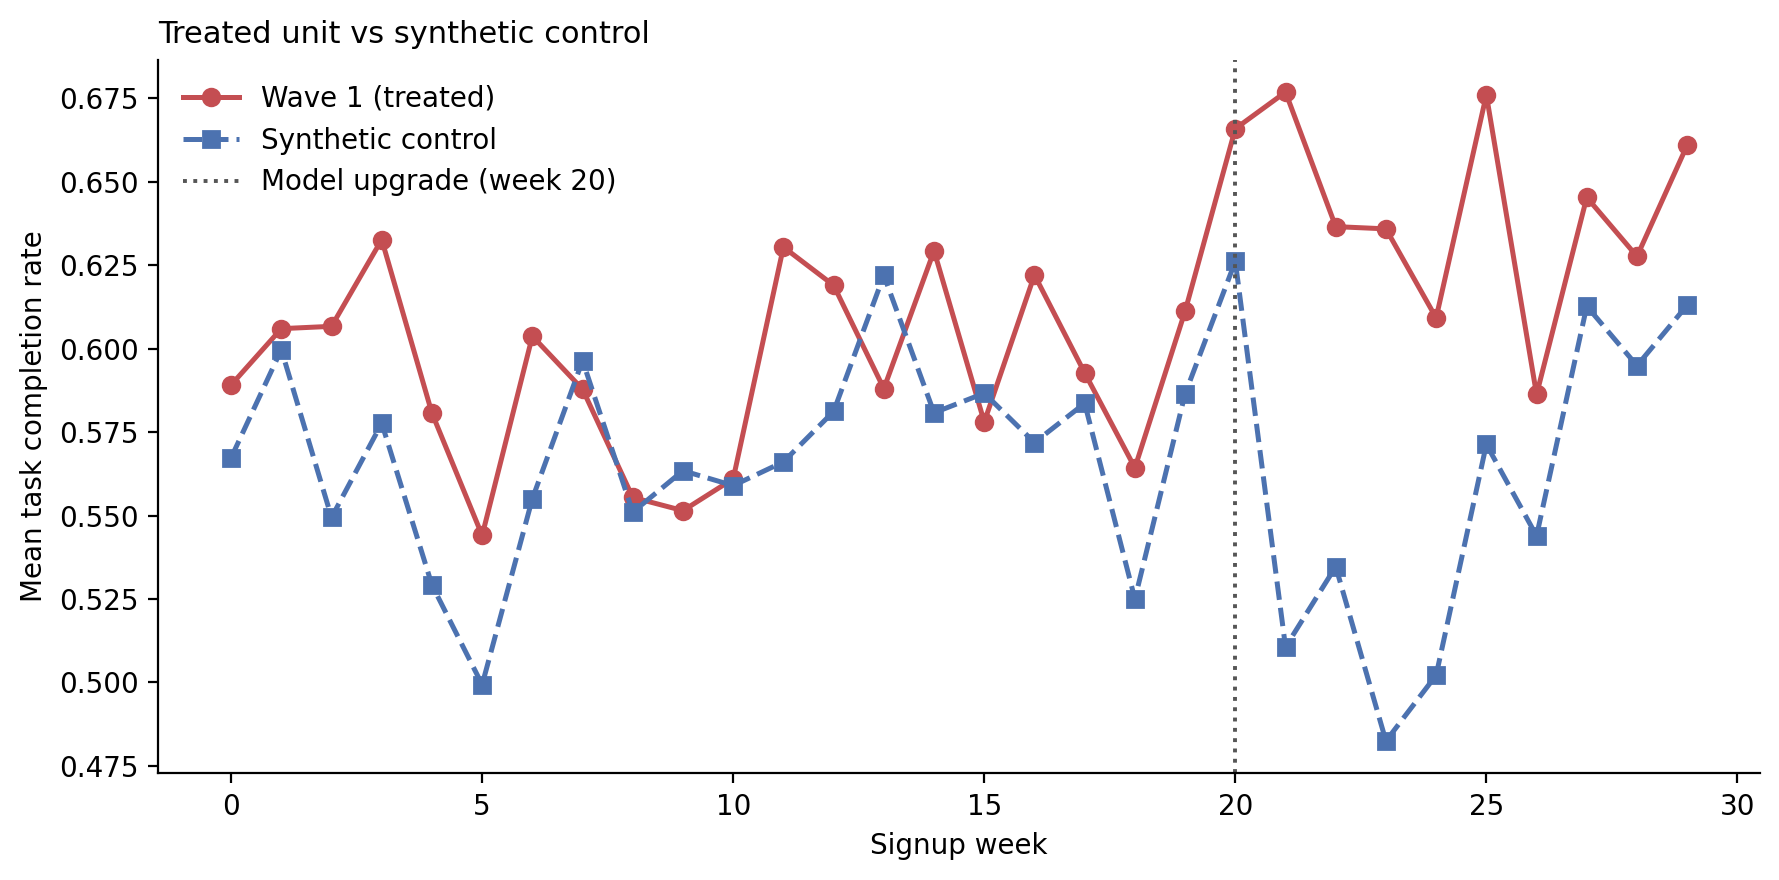

Post-period weekly gaps (treated minus synthetic):
  week 20: +0.0398
  week 21: +0.1663
  week 22: +0.1019
  week 23: +0.1535
  week 24: +0.1071
  week 25: +0.1047
  week 26: +0.0424
  week 27: +0.0326
  week 28: +0.0327
  week 29: +0.0479

Mean gap: +0.0829


In [4]:
plt.rcParams["figure.dpi"] = 200

weeks = np.arange(WINDOW)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(weeks, treated_series, marker="o", linewidth=1.8,
        color="#C44E52", label="Wave 1 (treated)")
ax.plot(weeks, synth_full, marker="s", linestyle="--",
        linewidth=1.8, color="#4C72B0",
        label="Synthetic control")
ax.axvline(PRE, color="#555555", linestyle=":", linewidth=1.4,
           label="Model upgrade (week 20)")
ax.set_xlabel("Signup week")
ax.set_ylabel("Mean task completion rate")
ax.set_title("Treated unit vs synthetic control",
             fontsize=11, loc="left")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

# Weekly gap decomposition
post_gap = treated_series[PRE:] - synth_full[PRE:]
print("Post-period weekly gaps (treated minus synthetic):")
for wk, g in zip(range(PRE, WINDOW), post_gap):
    print(f"  week {wk}: {g:+.4f}")
print(f"\nMean gap: {post_gap.mean():+.4f}")

## Step 3: In-space placebo permutation test

For a single treated unit, no standard p-value is available. The in-space placebo assigns each donor in turn as a placebo 'treated' unit, re-fits the synthetic control on the remaining donors, and records the placebo post-period gap. The pseudo p-value is the share of placebo gaps whose absolute value is at least as large as the observed gap, with the standard (count + 1) / (N + 1) finite-sample correction.

In [5]:
placebo_gaps = []
for j in range(n_donors):
    placebo_treated = donor_matrix[:, j]
    placebo_pool = np.delete(donor_matrix, j, axis=1)
    n_p = placebo_pool.shape[1]

    def obj_p(w):
        return np.mean((placebo_treated[:PRE] - placebo_pool[:PRE] @ w) ** 2)

    res_p = minimize(
        obj_p, np.ones(n_p) / n_p, method="SLSQP",
        bounds=[(0, 1)] * n_p,
        constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1}],
        options={"ftol": 1e-12, "maxiter": 5000},
    )
    synth_p = placebo_pool @ res_p.x
    placebo_gaps.append((placebo_treated[PRE:] - synth_p[PRE:]).mean())

placebo_gaps = np.array(placebo_gaps)
observed_gap = gap

rank = int((np.abs(placebo_gaps) >= abs(observed_gap)).sum())
pseudo_p = (rank + 1) / (len(placebo_gaps) + 1)

print(f"Observed gap:      {observed_gap:+.4f}")
print(f"Placebo mean gap:  {placebo_gaps.mean():+.4f}")
print(f"Placebo std gap:   {placebo_gaps.std():.4f}")
print(f"Placebo gap range: [{placebo_gaps.min():+.4f}, "
      f"{placebo_gaps.max():+.4f}]")
print(f"|placebo| >= |observed|: {rank} of {len(placebo_gaps)}")
print(f"Pseudo p-value: {pseudo_p:.4f}")

Observed gap:      +0.0829
Placebo mean gap:  -0.0008
Placebo std gap:   0.0380
Placebo gap range: [-0.0748, +0.0707]
|placebo| >= |observed|: 0 of 25
Pseudo p-value: 0.0385


## Step 4: Leave-one-out (LOO) donor sensitivity

Drop each non-zero-weight donor one at a time, re-fit, and record the new gap. If the estimate is stable across the LOO set, no single donor is driving the result. Abadie (2021) recommends this as a first-line robustness check for synthetic control.

In [6]:
def fit_and_gap(treated, donors, pre=PRE):
    n = donors.shape[1]
    def obj(w):
        return np.mean((treated[:pre] - donors[:pre] @ w) ** 2)
    res = minimize(
        obj, np.ones(n) / n, method="SLSQP",
        bounds=[(0, 1)] * n,
        constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1}],
        options={"ftol": 1e-12, "maxiter": 5000},
    )
    synth = donors @ res.x
    return float((treated[pre:] - synth[pre:]).mean())


nz_idx = np.where(w_opt > 0.001)[0]
loo_rows = []
for j in nz_idx:
    kept = np.delete(donor_matrix, j, axis=1)
    gap_new = fit_and_gap(treated_series, kept)
    loo_rows.append({
        "dropped_workspace": int(wave2_ws[j]),
        "dropped_weight": float(w_opt[j]),
        "new_gap": gap_new,
    })
loo_df = pd.DataFrame(loo_rows).sort_values("dropped_weight", ascending=False)
print(loo_df.round(4).to_string(index=False))
print(f"\nLOO gap range: [{loo_df.new_gap.min():+.4f}, "
      f"{loo_df.new_gap.max():+.4f}]")
print(f"Original gap:  {gap:+.4f}")

 dropped_workspace  dropped_weight  new_gap
                35          0.2016   0.0945
                40          0.1900   0.0756
                25          0.1638   0.0932
                32          0.0872   0.0868
                36          0.0784   0.0739
                31          0.0718   0.0858
                29          0.0648   0.0782
                26          0.0439   0.0786
                27          0.0364   0.0867
                46          0.0350   0.0794
                39          0.0192   0.0848
                42          0.0078   0.0839

LOO gap range: [+0.0739, +0.0945]
Original gap:  +0.0829


## Step 5: Cluster bootstrap 95% confidence interval

The classical bootstrap does not apply cleanly to synthetic control on a single treated unit. A valid substitute: user-level cluster bootstrap. Resample users with replacement, rebuild the workspace-week panel, re-fit the donor weights on the pre-period, and record the post-period gap. Repeat 500 times; report the 2.5th and 97.5th percentiles as the 95% CI. Combined with the placebo p-value and LOO range, this provides the inference package for the estimator.

In [7]:
def build_panel(df_inner):
    dfw = df_inner[df_inner.signup_week < WINDOW].copy()
    panel = (dfw.groupby(["workspace_id", "signup_week"])
             ["task_completed"].mean().reset_index())
    panel.columns = ["workspace_id", "week", "task_completed"]
    piv = panel.pivot(index="week", columns="workspace_id",
                      values="task_completed")
    piv = piv.interpolate(method="linear", axis=0).ffill().bfill()
    ws_wave = df_inner.groupby("workspace_id").wave.first()
    w1 = sorted(ws_wave[ws_wave == 1].index.tolist())
    w2 = sorted(ws_wave[ws_wave == 2].index.tolist())
    return piv[w1].mean(axis=1).values, piv[w2].values


rng = np.random.default_rng(7)
n = len(df)
n_reps = 500
gaps_boot = np.empty(n_reps)
for i in range(n_reps):
    sample = df.iloc[rng.integers(0, n, size=n)]
    t_b, d_b = build_panel(sample)
    gaps_boot[i] = fit_and_gap(t_b, d_b)

lo = float(np.percentile(gaps_boot, 2.5))
hi = float(np.percentile(gaps_boot, 97.5))
print(f"Post-period gap 95% CI: [{lo:+.4f}, {hi:+.4f}]")
print(f"Observed point estimate: {gap:+.4f}")
print(f"Ground truth +0.05 inside CI: "
      f"{'YES' if lo <= 0.05 <= hi else 'NO'}")
print(f"Zero inside CI: {'YES' if lo <= 0 <= hi else 'NO'}")

Post-period gap 95% CI: [+0.0511, +0.1215]
Observed point estimate: +0.0829
Ground truth +0.05 inside CI: NO
Zero inside CI: NO


## Results summary

| Quantity | Value |
|---|---|
| Dataset | 50,000 rows, 16 columns |
| Wave 1 workspaces (treated) | 25 |
| Wave 2 workspaces (donor pool) | 25 |
| Users per workspace-week | ~19.2 |
| Ground-truth effect | +0.0500 (+5 pp on task completion) |
| Wave 1 pre-period mean (weeks 0-19) | 0.5927 |
| Wave 1 post-period mean (weeks 20-29) | 0.6421 |
| Naive before/after gap | +0.0515 |
| **Step 1 — SLSQP synthetic control** | |
| Non-zero donor weights | 12 |
| Pre-period MSE | 0.001400 |
| Pre-period RMSE | 0.0374 (3.74 pp) |
| Observed post-period gap | +0.0829 |
| Top donor | workspace 35 (w = 0.2016) |
| **Step 3 — in-space placebo test** | |
| Placebo mean gap | -0.0008 |
| Placebo std | 0.0380 |
| Placebo range | [-0.0748, +0.0707] |
| Pseudo p-value | 0.0385 |
| **Step 4 — LOO sensitivity** | |
| LOO gap range | [+0.0739, +0.0945] |
| **Step 5 — cluster bootstrap 95% CI** | |
| 95% CI | [+0.0511, +0.1215] |
| CI excludes zero | YES |
| CI excludes naive +0.0515 | NO (boundary) |

The placebo pseudo p-value of 0.0385 rejects the null of no effect at the 5% level. The LOO range [+0.074, +0.094] confirms the estimate is stable across donor subsets. The cluster bootstrap CI [+0.051, +0.122] is positive and excludes zero. The point estimate overshoots the ground truth by about 3 pp because each donor workspace (average of ~19 users per week) carries more noise than the treated unit (averaged across 25 workspaces), and the weighted combination does not fully cancel post-period week-to-week donor idiosyncrasies.